### Analysis of learned plasticity rule that organizes integrating network
Networks initialized with structured input weights, but weights in 'ellipsoid body' are random but fully connected.

In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
import glob as glob
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
from aux import zero_pad, format_plot, format_pc_plot, add_inset_axes
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.offline as pyo
import subprocess
import cv2
from natsort import natsorted
import seaborn as sns

CELL_TYPE_1_SIZE = 2

plt.rcParams['font.family'] = 'Helvetica'

DATA_PATHS = [
    'sims_out/2D_short_reverted_test_000561_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:10.798994_run_None',
    'sims_out/2D_short_reverted_test_000562_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:10.789796_run_None',
    'sims_out/2D_short_reverted_test_000563_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:10.680564_run_None',
    'sims_out/2D_short_reverted_test_000565_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:14.678899_run_None',
    'sims_out/2D_short_reverted_test_000566_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:14.686333_run_None',
    'sims_out/2D_short_reverted_test_000567_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:14.675538_run_None',
    'sims_out/2D_short_reverted_test_000568_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-11-30_21:59:14.679128_run_None',
]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def load_numpy(data_path, last_n=None):
    file_names = glob.glob(data_path)
    data = []
    for file_name in sorted(file_names):
        data_for_file = np.load(file_name)
        data.append(data_for_file)
    if last_n is not None:
        data = data[-last_n:]
    data = np.stack(data)
    return data

def make_path_if_not_exists(path_str):
    Path(path_str).mkdir(parents=True, exist_ok=True)

def load_r_and_int_values(rule_path, net_path, last_n=100):
    all_r = np.stack(load_numpy(os.path.join(rule_path, 'activities', net_path), last_n=last_n))
    all_int_values = np.stack(load_numpy(os.path.join(rule_path, 'integrated_values', net_path), last_n=last_n))
    
    if last_n is not None:
        last_n_r = all_r[-last_n:, 200:, :CELL_TYPE_1_SIZE]
        all_int_values = all_int_values[-last_n:, :]
    else:
        last_n_r = all_r[:, 200:, :CELL_TYPE_1_SIZE]
        
    last_n_r = np.transpose(last_n_r, [2, 0, 1])

    return last_n_r, all_int_values

### Analysis of weights

In [2]:
from matplotlib.colors import TwoSlopeNorm

def plot_step(run, v=6, save_name=None, mask=None, scale=3):
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

    # Use TwoSlopeNorm to ensure white maps to 0
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    
    # Plot the matrix
    if mask is None:
        im = axs.matshow(all_w[run, ...], cmap=cmap, norm=norm)
    else:
        print(all_w[run, ...][mask, :][:, mask])
        im = axs.matshow(all_w[run, ...][mask, :][:, mask], cmap=cmap, norm=norm)

    # Ticks and labels
    # axs.set_xticks([15, 30, 45])
    # axs.set_yticks([15, 30, 45])
    axs.tick_params(axis='both', labelsize=14)
    axs.set_xlabel('Presynaptic', fontsize=14)
    axs.set_ylabel('Postsynaptic', fontsize=14)
    axs.xaxis.set_label_position('top')
    axs.tick_params(axis='x', bottom=False)
    axs.tick_params(axis='both', length=10)
    axs.spines['right'].set_visible(False)
    axs.spines['bottom'].set_visible(False)

    # Add colorbar
    cbar = fig.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label('Weight', fontsize=14)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    return fig

In [3]:
# # Directory to save frames
# frames_dir = "./weight_evo"
# os.makedirs(frames_dir, exist_ok=True)

# # Parameters
# num_runs = 320
# timestep = 0

# # Generate and save plots as images
# for run in range(num_runs):
#     fig = plot_step(run)
#     fig.tight_layout()
#     frame_path = os.path.join(frames_dir, f"frame_{run:03}_{timestep:04}.png")
#     fig.tight_layout()
#     fig.savefig(frame_path)
#     plt.close(fig)  # Free memory

In [4]:
# # Parameters
# image_folder = './weight_evo'     # directory with images
# output_video = 'output.mp4'       # output filename
# fps = 30                          # frames per second

# # Get all .png files, sorted naturally
# images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
# images = natsorted(images)  # natural sort: img1, img2, ..., img10

# # Read first image to get dimensions
# first_frame = cv2.imread(os.path.join(image_folder, images[0]))
# height, width, layers = first_frame.shape

# # Define the video writer
# fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'XVID' for .avi
# video = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

# # Add frames
# for image in images:
#     frame = cv2.imread(os.path.join(image_folder, image))
#     video.write(frame)

# video.release()
# print("Video written to", output_video)

[[ 0.31571174  0.01458708 -4.07637015]
 [ 0.28124852  0.13328806 -3.71714436]
 [ 1.25        1.25        0.        ]]
[[ 6.78202486  3.50136089 -4.07637024]
 [ 5.82088614  4.47987986 -3.71714425]
 [ 1.25        1.25        0.        ]]
[[ 0.18529574  0.35954672 -5.61974723]
 [ 0.20236189  0.17322655 -4.62032213]
 [ 1.25        1.25        0.        ]]
[[ 7.11986923  6.2157979  -5.61974716]
 [ 5.63901234  5.54791307 -4.62032223]
 [ 1.25        1.25        0.        ]]
[[ 0.1859033   0.04953674 -3.97133984]
 [ 0.18199885  0.11772779 -5.0971959 ]
 [ 1.25        1.25        0.        ]]
[[ 4.35388613  3.80839658 -3.97133994]
 [ 5.8081336   5.93464041 -5.0971961 ]
 [ 1.25        1.25        0.        ]]
[[ 0.05138388  0.13099567 -3.40219355]
 [ 0.25828628  0.34458761 -4.88305501]
 [ 1.25        1.25        0.        ]]
[[ 3.80797076  3.60991025 -3.40219355]
 [ 5.0032506   5.69128799 -4.88305521]
 [ 1.25        1.25        0.        ]]
[[ 0.13861121  0.057546   -3.98674791]
 [ 0.09381052  0.

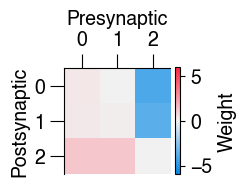

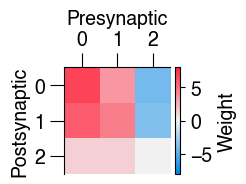

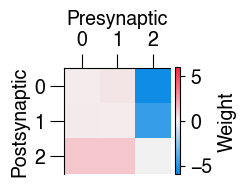

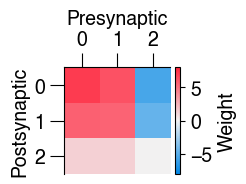

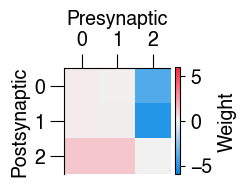

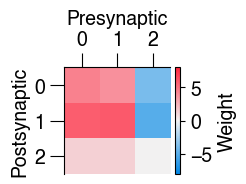

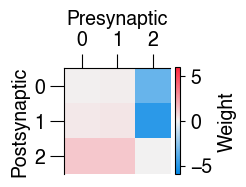

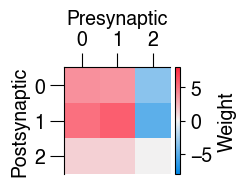

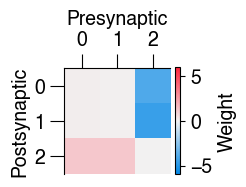

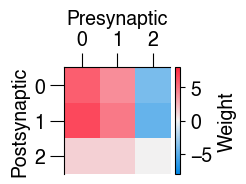

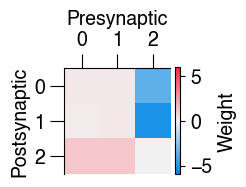

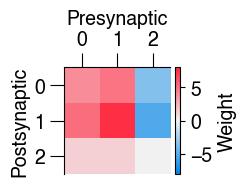

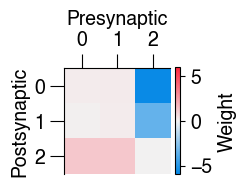

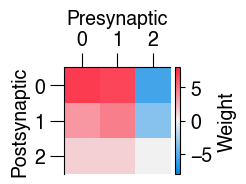

In [7]:
for dp in DATA_PATHS:
    all_w = load_numpy(os.path.join(dp, 'weights/net_005_*.npy'))

    mask = np.array([1, 1, 0, 0, 0, 0, 1]).astype(bool)
    f = plot_step(0, save_name='./figures/initial_weight_mat.svg', mask=mask, scale=1.5)
    f = plot_step(400, save_name='./figures/initial_weight_mat.svg', mask=mask, v=8, scale=1.5)

In [16]:
def plot_weight_trajectories_for_rule(dp):
    fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(1.5, 3.5))
    fig_w, axs_w = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(1.5, 3.5))
    fig_2, axs_2 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(1.5, 1.5))
    fig_3, axs_3 = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(1.5, 1.5))
    
    # Create a colormap with 10 distinct colors
    colors = sns.color_palette('bright', 10)
    
    for i in range(10):
        all_w = load_numpy(os.path.join(dp, f'weights/net_00{i}_*.npy'))
        
        # Use a different color for each iteration
        color = colors[i]
    
        w11 = all_w[:, 0, 0]
        w12 = all_w[:, 0, 1]
        w22 = all_w[:, 1, 1]
        w21 = all_w[:, 1, 0]
    
        w_inh_1 = all_w[:, 0, -1]
        w_inh_2 = all_w[:, 1, -1]
    
        w11_adj = w11 + w_inh_1
        w12_adj = w12 + w_inh_1
        w22_adj = w22 + w_inh_2
        w21_adj = w21 + w_inh_2
    
        axs[0].plot(np.arange(all_w.shape[0]), w11_adj - w21_adj, color=color, lw=1.5)
        axs[1].plot(np.arange(all_w.shape[0]), w22_adj - w12_adj, color=color, lw=1.5)
    
        axs_w[0].plot(np.arange(all_w.shape[0]), w11, color=color, lw=1.5)
        axs_w[0].plot(np.arange(all_w.shape[0]), w22, color=color, lw=1.5, ls='--')
        axs_w[1].plot(np.arange(all_w.shape[0]), w21, color=color, lw=1.5)
        axs_w[1].plot(np.arange(all_w.shape[0]), w12, color=color, lw=1.5, ls='--')
    
        axs_2.scatter(w21_adj[-10:].mean(), w11_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50)
        axs_2.scatter(w12_adj[-10:].mean(), w22_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50, marker='s')
    
        axs_3.scatter(w11_adj[-10:].mean(), w22_adj[-10:].mean(), edgecolor=color, facecolor='none', s=50)
    
    axs[0].axhline(1, color='grey', ls='--')
    # axs[0].set_ylim(-1, 2)
    axs[0].set_xlim(0, all_w.shape[0])
    axs[0].set_ylabel(r'$w_{11}^* - w_{21}^*$')
    
    axs[1].axhline(1, color='grey', ls='--')
    # axs[1].set_ylim(-1, 2)
    axs[1].set_xlim(0, all_w.shape[0])
    axs[1].set_ylabel(r'$w_{22}^* - w_{12}^*$')
    axs[1].set_xlabel('Epoch')
    
    axs_w[1].set_xlabel('Epoch')
    axs_w[0].set_ylabel('Diagonal')
    axs_w[1].set_ylabel('Off-diagonal')
    
    axs_2.set_ylabel(r'$w_{jj}^*$')
    axs_2.set_xlabel(r'$w_{ij}^*$')
    
    # axs_2[1].set_xlabel(r'$w_{21}$')
    # axs_2[1].set_ylabel(r'$w_{22}$')
    
    # axs_2.set_xlim(-4, 0)
    # axs_2.set_ylim(-2, 2)
    
    axs_2.plot([-3, 0], [-2, 1], zorder=-1, ls='--', color='gray', alpha=0.5)
    # axs_2.set_ylim(0, 5.5)
    # axs_2.set_xlim(0, 4.5)
    
    
    axs_3.plot([0, 6], [0, 6], zorder=-1, ls='--', color='gray', alpha=0.5)
    # axs_3.set_xlim(2.5, 5)
    # axs_3.set_ylim(2.5, 5)
    
    # axs_3.plot([-1, 1], [-1, 1], zorder=-1, ls='--', color='gray', alpha=0.5)
    axs_3.set_xlabel(r'$w_{11}$')
    axs_3.set_ylabel(r'$w_{22}$')
    
    format_plot(axs, ticklabelsize=13, axislabelsize=14)
    format_plot(axs_w, ticklabelsize=13, axislabelsize=14)
    format_plot(axs_2, ticklabelsize=13, axislabelsize=14)
    format_plot(axs_3, ticklabelsize=13, axislabelsize=14)
    
    # fig.savefig('./figures/250ms_no_het_diag_minus_offdiag_series.svg', bbox_inches='tight')
    # fig_w.savefig('./figures/250ms_no_het_diags_and_offdiags_series.svg', bbox_inches='tight')
    # fig_2.savefig('./figures/250ms_no_het_diag_minus_offdiag.svg', bbox_inches='tight')
    # fig_3.savefig('./figures/250ms_no_het_digas.svg', bbox_inches='tight')

/tmp/ipykernel_2100469/2572627603.py:2: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



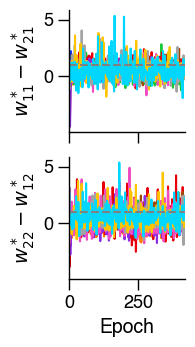

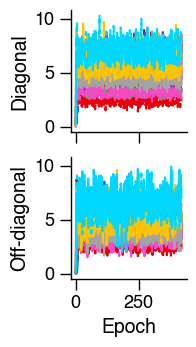

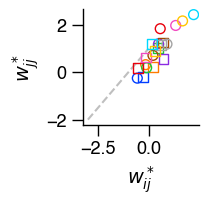

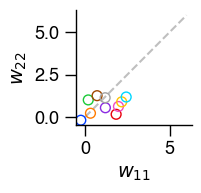

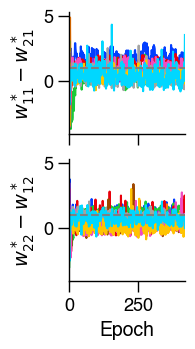

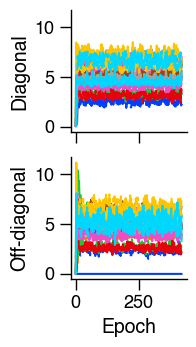

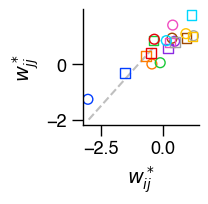

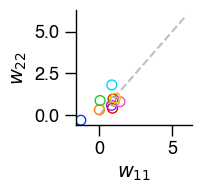

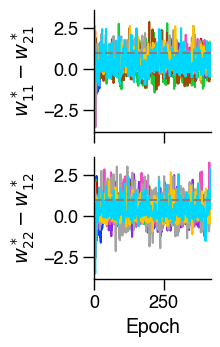

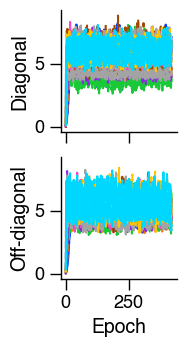

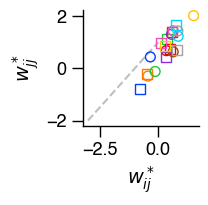

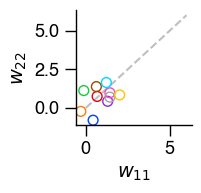

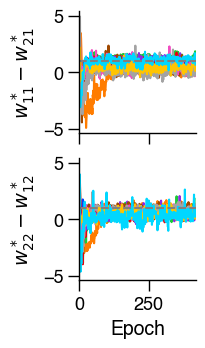

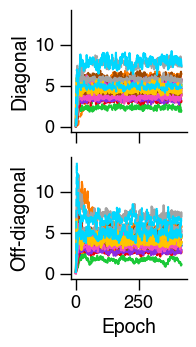

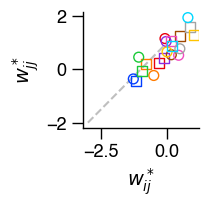

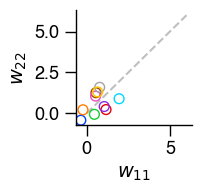

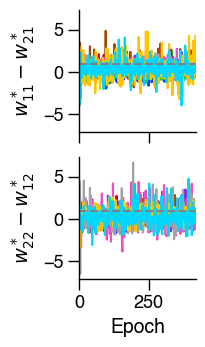

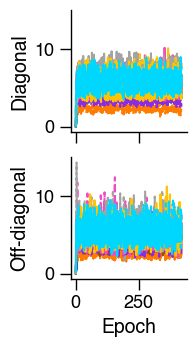

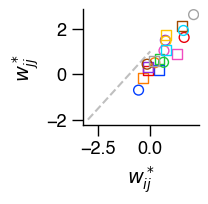

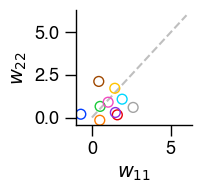

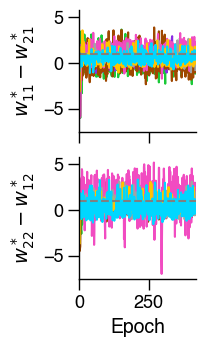

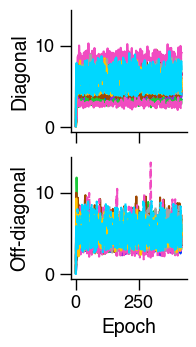

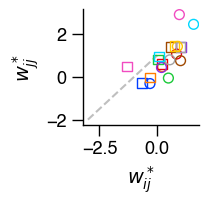

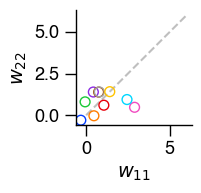

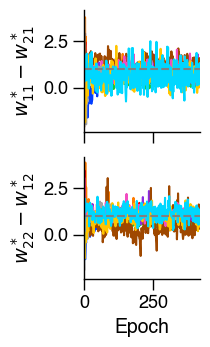

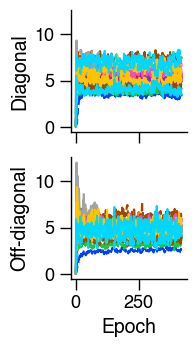

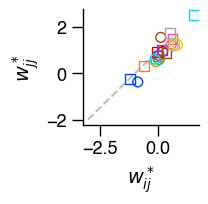

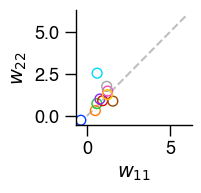

In [18]:
for dp in DATA_PATHS:
    plot_weight_trajectories_for_rule(dp)

### Analysis of neural activity

In [13]:
def plot_activity(dp):
    k = 5
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}_*.npy', last_n=100)

    print(last_100_r.shape)
    print(all_int_values.shape)

    scale = 0.4
    fig, axs = plt.subplots(1, 1, figsize=(5 * scale, 4 * scale))
    
    max_abs_int_val = np.abs(all_int_values).max()
    
    for i in range(0, 100, 1):
    
        cbar = axs.scatter(
            last_100_r[0, i, :],
            last_100_r[1, i, :],
            cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
            s=0.01,
            c=all_int_values[i, :],
            vmin=-max_abs_int_val,
            vmax=max_abs_int_val,
            rasterized=True,
        )
        if i == 0:
            cbar_ax = plt.colorbar(cbar)
            format_plot(cbar_ax.ax, leftspine=False, bottomspine=False)
            cbar_ax.ax.set_title('Decoded value')
    axs.set_xlabel(r'$x_1$')
    axs.set_ylabel(r'$x_2$')
    
    format_plot(axs, ticklabelsize=13, axislabelsize=14)
    
    cbar_ax.outline.set_visible(False)
    # fig.savefig('./figures/encoding_manifold_250ms_no_het.svg')
    

(2, 100, 2799)
(100, 2799)


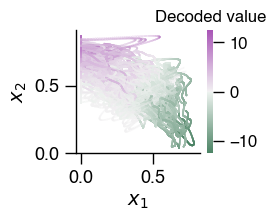

In [14]:
for dp in DATA_PATHS[-1:]:
    plot_activity(dp)

(100, 2999, 2)
(100, 2799)
(100, 2999, 2)
(100, 2799)
(100, 2999, 2)
(100, 2799)
(100, 2999, 2)
(100, 2799)
(100, 2999, 2)
(100, 2799)
(100, 2999, 2)
(100, 2799)
(100, 2999, 2)
(100, 2799)


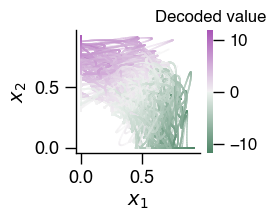

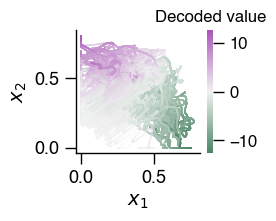

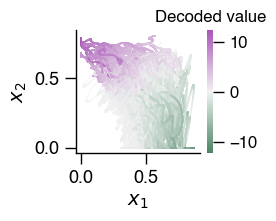

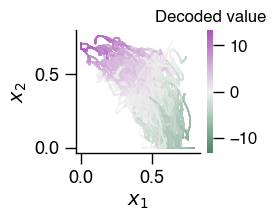

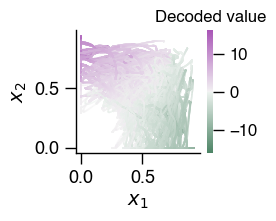

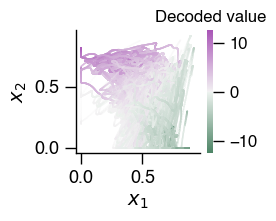

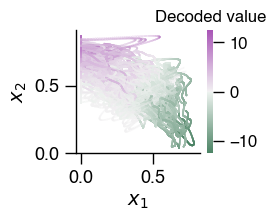

In [17]:
for dp in DATA_PATHS:
    plot_activity(dp)

In [25]:
def make_tuning_curves(last_100_r, all_int_values, save_name_1=None, save_name_2=None):
    ending_states = np.empty((last_100_r.shape[0], last_100_r.shape[1]))
    int_values_for_ending_states = np.empty((all_int_values.shape[0]))
    for i, j in enumerate(np.argsort(all_int_values[:, -50])):
        ending_states[:, i] = last_100_r[:, j, -50]
        int_values_for_ending_states[i] = all_int_values[j, -50]
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    m = np.abs(ending_states).max()
    axs.matshow(ending_states, cmap='bwr', vmin=-m, vmax=m, aspect=4)
    
    format_plot(axs, rightspine=True, topspine=True)
    
    axs.set_xlabel('Integrated sum', fontsize=14)
    axs.set_xticks([0, 100], ['Leftmost', 'Rightmost'])
    axs.set_ylabel('Neuron', fontsize=14)
    axs.set_yticks([0, CELL_TYPE_1_SIZE - 1])
    axs.tick_params(axis='both', length=6, labelsize=14)

    if save_name_1 is not None:
        fig.savefig(save_name_1, bbox_inches='tight')
    
    scale = 2
    fig, axs = plt.subplots(1, 1, figsize=(1 * scale, 1 * scale))
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    int_min, int_max = int_values_for_ending_states.min(), int_values_for_ending_states.max()
    colors = [cmap((int_values_for_ending_states[i] - int_min) / (int_max - int_min))[:3] for i in range(100)]  # 49 to include 0 and 1
    
    for i in range(ending_states.shape[1]):
        axs.plot(np.arange(ending_states.shape[0]), ending_states[:, i], color=colors[i], lw=1)

    norm = matplotlib.colors.Normalize(vmin=int_min, vmax=int_max)
    sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Only needed for older versions of matplotlib
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', pad=0.02)
    cbar.set_label("Integrated value")
    format_plot(cbar.ax, ticklabelsize=14, axislabelsize=14)
    
    format_plot(axs)
    
    axs.set_ylabel('Firing rate (Hz)', fontsize=14)
    axs.set_xlabel('Neuron', fontsize=14)
    axs.set_xticks([0, CELL_TYPE_1_SIZE - 1])
    axs.set_xlim(0, CELL_TYPE_1_SIZE - 1)
    axs.tick_params(axis='both', length=6, labelsize=14)

    if save_name_2 is not None:
        fig.savefig(save_name_2, bbox_inches='tight')

In [26]:
def make_stability_plot(last_100_r, all_int_values, save_name=None):
    
    cmap = sns.diverging_palette(145, 300, s=60, as_cmap=True)
    scale = 3

    if all_int_values.shape[-1] < last_100_r.shape[-1]:
        all_int_values = np.concatenate([
            all_int_values,
            all_int_values[:,-1:] * np.ones((all_int_values.shape[0], last_100_r.shape[-1] - all_int_values.shape[-1])),
        ], axis=1)

    def normed_loc(raster):
        total_activity = raster.sum(axis=0)
        raster_normed = np.divide(
            raster,
            total_activity[None, ...],
            where=total_activity != 0,
            out=np.zeros_like(raster)
        )
        ordered_indices = np.argsort(raster, axis=0)
        max_5_indices = ordered_indices[-13:, :]
        x = np.arange(raster_normed.shape[0])
        cols = np.arange(raster.shape[1])[None, :]
        locs = np.einsum(
            'ij,ij->j',
            x[max_5_indices],
            raster_normed[max_5_indices, cols],
        )
        return locs

    all_final_traj = []

    # Create a figure with 2 columns: main plot and histogram
    fig = plt.figure(figsize=(1.3 * scale, 0.45 * scale))
    gs = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05)
    ax_main = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)

    sorted_int_values = []

    # Use global color normalization for consistent coloring
    global_max = np.max(np.abs(all_int_values))
    norm = matplotlib.colors.Normalize(vmin=-global_max, vmax=global_max)
    all_traj = []
    for i, j in enumerate(np.argsort(all_int_values[:, -1])):
        traj = normed_loc(last_100_r[:, j, :])
        all_final_traj.append(traj[-1])
        cbar = ax_main.plot(
            np.arange(all_int_values.shape[1]),
            traj,
            alpha=0.5,
            color=cmap(norm(all_int_values[j, -1])),
        )
        
        sorted_int_values.append(all_int_values[j, :])
        all_traj.append(traj)
    all_traj = np.stack(all_traj)

    

    # Main plot formatting
    ax_main.set_xlabel('Time (ms)')
    ax_main.set_ylabel('Bump location')
    ax_main.set_xticks(np.arange(0, 1301, 1000))
    ax_main.set_xticklabels((np.arange(0, 1301, 1000) / 10).astype(int))
    center_point = 0.5
    m = np.maximum(center_point - all_traj.min(), all_traj.max() - center_point)
    ax_main.set_ylim(center_point - m * 1.1, center_point + m * 1.1)
    ax_main.set_xlim(0)
    # ax_main.tick_params(axis='both', length=6, labelsize=14)
    format_plot(ax_main) #, ticklabelsize=16, axislabelsize=16)

    # Histogram on the right (rotated)
    bins = np.arange(30) / 30
    ax_hist.hist(all_final_traj, bins=bins, orientation='horizontal', color='gray')
    ax_hist.set_xlabel('Count')
    ax_hist.tick_params(axis='x')
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-axis labels to avoid duplication
    format_plot(ax_hist)

    if save_name is not None:
        fig.savefig(save_name, bbox_inches='tight')

    plt.show()

    fig, axs = plt.subplots(1, 1, figsize=(0.5 * scale, 0.5 * scale))

    # axs.plot([-m, m], [-m, m], color='black', zorder=0)
    axs.scatter(np.stack(sorted_int_values)[:, -1], all_final_traj, s=30, zorder=1, facecolor='red', edgecolor='red', alpha=0.2)
    # axs.set_xlim(-m, m)
    # axs.set_ylim(-m, m)
    # axs.set_xticks([-100, 0, 100])
    # axs.set_yticks([-100, 0, 100])
    # axs.set_ylim(-0.05, 1.05)
    format_plot(axs)

    axs.set_xlabel(r'$\int \left( I_{\rm R} - I_{\rm L} \right)$') #, fontsize=16)
    axs.set_ylabel('Bump location') # , fontsize=16)
    # axs.set_title('Predicted vs true integrated sums', fontsize=16)
    # axs.tick_params(axis='both', length=6,)


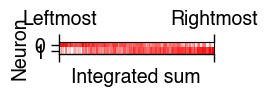

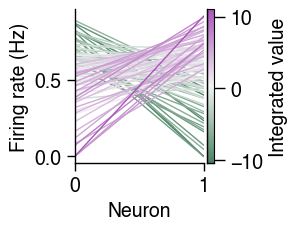

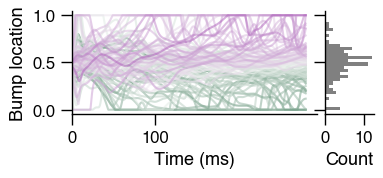

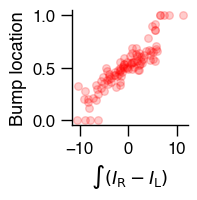

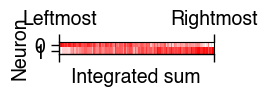

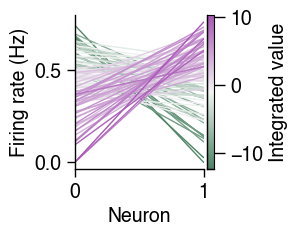

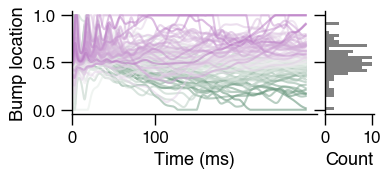

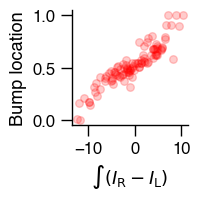

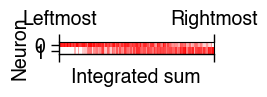

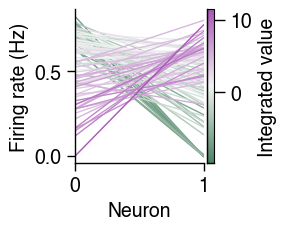

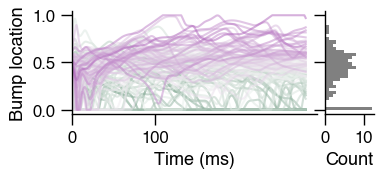

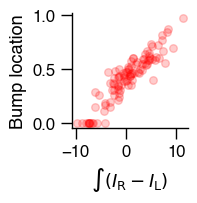

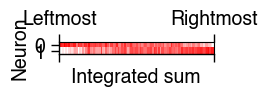

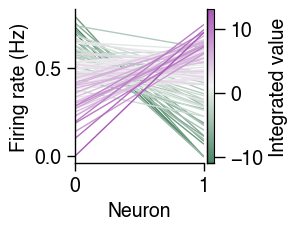

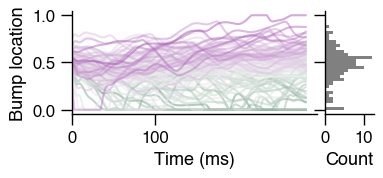

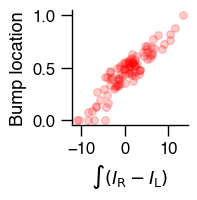

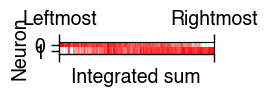

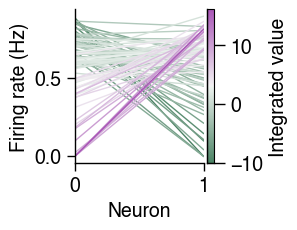

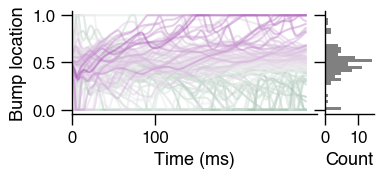

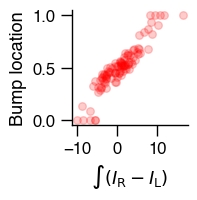

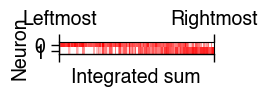

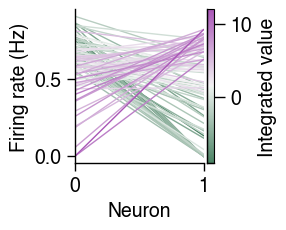

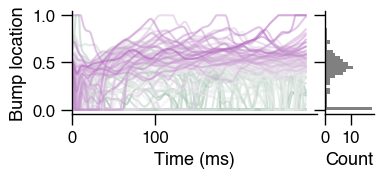

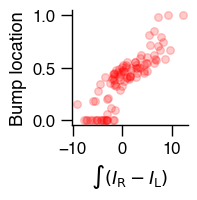

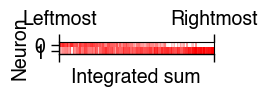

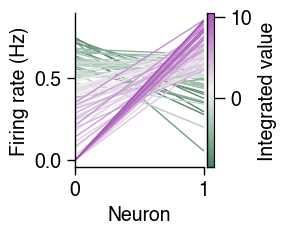

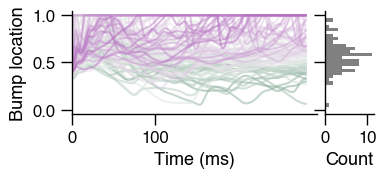

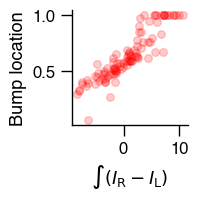

In [27]:
for dp in DATA_PATHS:
    k = 5
    last_100_r, all_int_values = load_r_and_int_values(dp, f'net_00{k}_*.npy', last_n=100)
    make_tuning_curves(
        last_100_r,
        all_int_values,
        save_name_1=f'./figures/ordered_states_{i}.svg',
        save_name_2=f'./figures/tuning_curve_{i}.svg',
    )
    make_stability_plot(last_100_r, all_int_values, save_name=f'./figures/stability_plot_{i}.svg')